# Import Libraries

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt



# Reading the Data

In [2]:
train = pd.read_csv("../data/raw/train_BRCpofr.csv.zip", compression="zip")
test = pd.read_csv("../data/raw/test_koRSKBP.csv.zip", compression="zip")

In [3]:
train.tail()

,id,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy,cltv
89387,89388,Male,Rural,High School,More than 10L,0,6,0,More than 1,B,Platinum,95736
89388,89389,Male,Urban,Bachelor,5L-10L,1,0,3897,More than 1,A,Platinum,67596
89389,89390,Female,Urban,Bachelor,5L-10L,0,4,3363,More than 1,B,Platinum,114120
89390,89391,Female,Rural,High School,2L-5L,0,8,0,More than 1,B,Platinum,71772
89391,89392,Female,Rural,High School,5L-10L,0,6,0,More than 1,B,Gold,108144


In [4]:
test.head()

,id,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy
0,89393,Female,Rural,High School,5L-10L,0,6,2134,More than 1,B,Silver
1,89394,Female,Urban,High School,2L-5L,0,4,4102,More than 1,A,Platinum
2,89395,Male,Rural,High School,5L-10L,1,7,2925,More than 1,B,Gold
3,89396,Female,Rural,Bachelor,More than 10L,1,2,0,More than 1,B,Silver
4,89397,Female,Urban,High School,2L-5L,0,5,14059,More than 1,B,Silver


In [5]:
train.shape, test.shape

((89392, 12), (59595, 11))

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89392 entries, 0 to 89391
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              89392 non-null  int64 
 1   gender          89392 non-null  object
 2   area            89392 non-null  object
 3   qualification   89392 non-null  object
 4   income          89392 non-null  object
 5   marital_status  89392 non-null  int64 
 6   vintage         89392 non-null  int64 
 7   claim_amount    89392 non-null  int64 
 8   num_policies    89392 non-null  object
 9   policy          89392 non-null  object
 10  type_of_policy  89392 non-null  object
 11  cltv            89392 non-null  int64 
dtypes: int64(5), object(7)
memory usage: 8.2+ MB


In [7]:
train.tail()

,id,gender,area,qualification,income,marital_status,vintage,claim_amount,num_policies,policy,type_of_policy,cltv
89387,89388,Male,Rural,High School,More than 10L,0,6,0,More than 1,B,Platinum,95736
89388,89389,Male,Urban,Bachelor,5L-10L,1,0,3897,More than 1,A,Platinum,67596
89389,89390,Female,Urban,Bachelor,5L-10L,0,4,3363,More than 1,B,Platinum,114120
89390,89391,Female,Rural,High School,2L-5L,0,8,0,More than 1,B,Platinum,71772
89391,89392,Female,Rural,High School,5L-10L,0,6,0,More than 1,B,Gold,108144


In [8]:
train.describe()

,id,marital_status,vintage,claim_amount,cltv
count,89392.000000,89392.000000,89392.000000,89392.000000,89392.000000
mean,44696.500000,0.575488,4.595669,4351.502416,97952.828978
std,25805.391969,0.494272,2.290446,3262.359775,90613.814793
min,1.000000,0.000000,0.000000,0.000000,24828.000000
25%,22348.750000,0.000000,3.000000,2406.000000,52836.000000
50%,44696.500000,1.000000,5.000000,4089.000000,66396.000000
75%,67044.250000,1.000000,6.000000,6094.000000,103440.000000
max,89392.000000,1.000000,8.000000,31894.000000,724068.000000


In [9]:
train.nunique()

id                89392
gender                2
area                  2
qualification         3
income                4
marital_status        2
vintage               9
claim_amount      10889
num_policies          2
policy                3
type_of_policy        3
cltv              18796
dtype: int64

# EDA

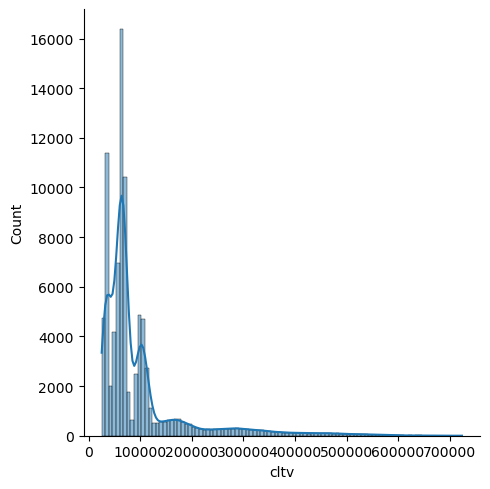

In [10]:
sns.displot(train['cltv'], kde=True, bins=100)
plt.show()

Looking at the graph we can see that the data is positively skewed(right-skewed) distribution. The vast majority of the customers are concetrated between 0 to 100,000, these makes up the everyday customers which have lower-value orders that makes up the bulk volume. Noticing the many peaks packed together shows we might have distinct customer segments within the general base. The dragged out long tail shows the "Whales" which buy the majority of the orders, they are the VIPs, even though they are few thier individual monetery contribution is massive.

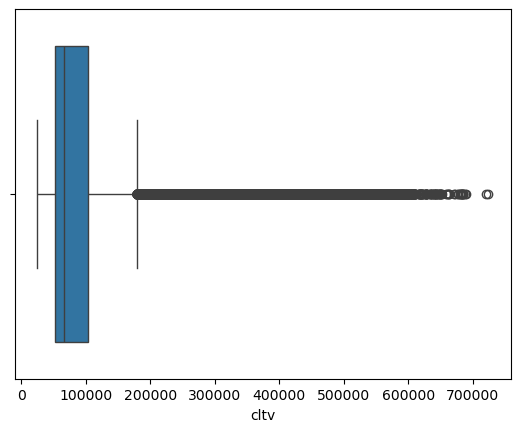

In [11]:
sns.boxplot(x=train['cltv'])
plt.show()

In [12]:
train['cltv'].skew(), train['cltv'].kurtosis()

(np.float64(2.7530651590601143), np.float64(8.333802797590577))

From the plot we can see the IQR which is 50% of the data compressed to the left mostly below 100,000 and the median line inside of it being at the left side of the box, shows the not only is the data skewed it is packed at low-value tranctions. Then we can see the transactions after the right-whiskers which are statistically known as outliers forming a thick line. This much exceptional case is to be noted.
Note the extreme skeweness and kurtosis.

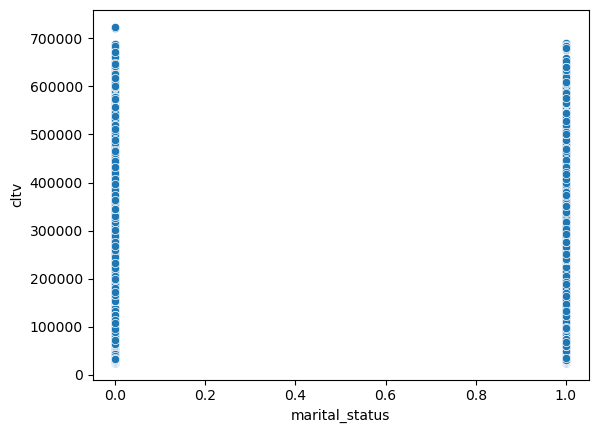

In [13]:
sns.scatterplot(x=train['marital_status'], y=train['cltv'])
plt.show()

This shows that low value that low-value and high-value exist in both demography(married and not married)

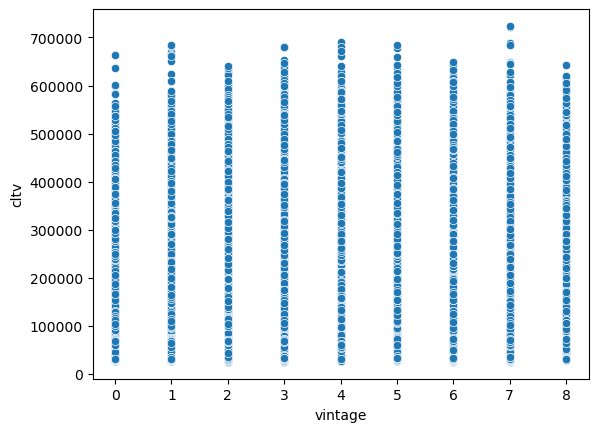

In [14]:
sns.scatterplot(x=train['vintage'], y=train['cltv'])
plt.show()

This shows that there is high-value and low-value in all vintage

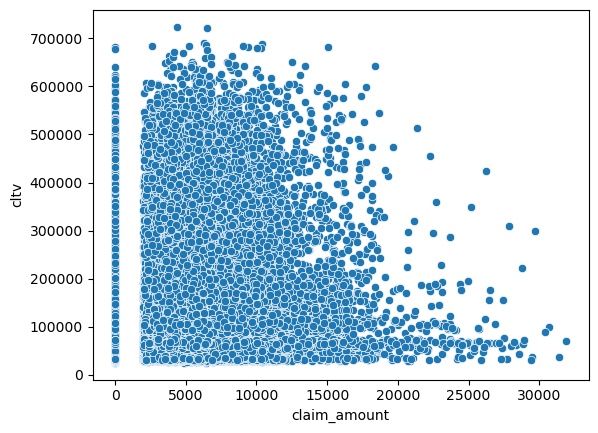

In [15]:
plt.show(sns.scatterplot(x=train['claim_amount'], y=train['cltv']))

This plot is fascinating as it reveals customers in the far left whom have never file for a claim, present in the low-value and the high-value, forming a straight line. Then to the right we can see that there is no linear relationship between cltv and claim amount, where we have dense blue-dots ranging roughly from 2,000 to 16,000 making up the majority of claims.
We can see that as custumer claim becomes more extreme, thier cltv drops drastically in fact almost no one has a cltv above 100,000 from 30,000 claim amout and above.

In [16]:
obj_cols = train.select_dtypes(include="object")
obj_cols.columns

Index(['gender', 'area', 'qualification', 'income', 'num_policies', 'policy',
       'type_of_policy'],
      dtype='object')

In [17]:
for obj in obj_cols:
    print("Unique values in", str(obj), "is", train[obj].nunique())
    print(train[obj].value_counts())
    print("-----------------------------------------")

Unique values in gender is 2
gender
Male      50497
Female    38895
Name: count, dtype: int64
-----------------------------------------
Unique values in area is 2
area
Urban    62455
Rural    26937
Name: count, dtype: int64
-----------------------------------------
Unique values in qualification is 3
qualification
High School    46247
Bachelor       39399
Others          3746
Name: count, dtype: int64
-----------------------------------------
Unique values in income is 4
income
5L-10L           52716
2L-5L            21158
More than 10L    13664
<=2L              1854
Name: count, dtype: int64
-----------------------------------------
Unique values in num_policies is 2
num_policies
More than 1    60263
1              29129
Name: count, dtype: int64
-----------------------------------------
Unique values in policy is 3
policy
A    56644
B    24635
C     8113
Name: count, dtype: int64
-----------------------------------------
Unique values in type_of_policy is 3
type_of_policy
Platinum  

In [18]:
for col in train:
    print("Unique values in", str(col), "is", train[col].nunique())
    print(train[col].value_counts())
    print("-" * 50)

Unique values in id is 89392
id
89376    1
89375    1
89374    1
89373    1
89372    1
        ..
5        1
4        1
3        1
2        1
1        1
Name: count, Length: 89392, dtype: int64
--------------------------------------------------
Unique values in gender is 2
gender
Male      50497
Female    38895
Name: count, dtype: int64
--------------------------------------------------
Unique values in area is 2
area
Urban    62455
Rural    26937
Name: count, dtype: int64
--------------------------------------------------
Unique values in qualification is 3
qualification
High School    46247
Bachelor       39399
Others          3746
Name: count, dtype: int64
--------------------------------------------------
Unique values in income is 4
income
5L-10L           52716
2L-5L            21158
More than 10L    13664
<=2L              1854
Name: count, dtype: int64
--------------------------------------------------
Unique values in marital_status is 2
marital_status
1    51444
0    37948
Na

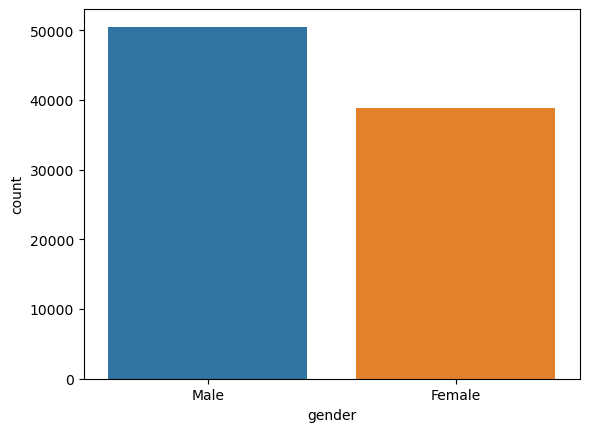

In [19]:
plt.show(sns.countplot(x=train['gender'], hue=train['gender']))

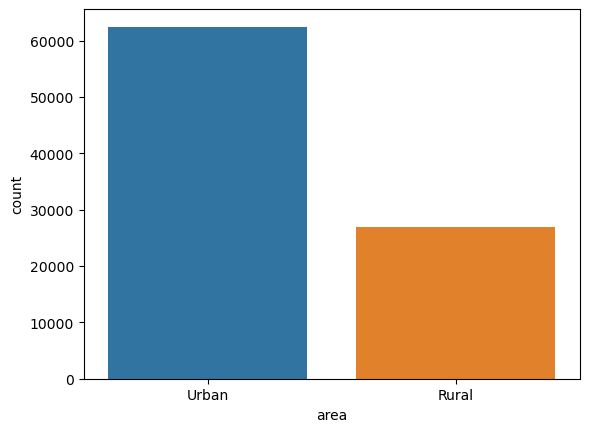

In [20]:
plt.show(sns.countplot(x=train['area'], hue=train['area']))

In [ ]:
plt.show(sns.countplot(x=train['qualification'], hue=train['qualification']))

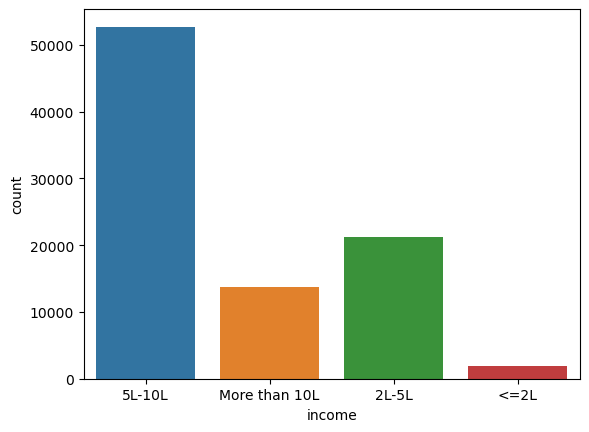

In [ ]:
plt.show(sns.countplot(x=train['income'], hue=train['income']))

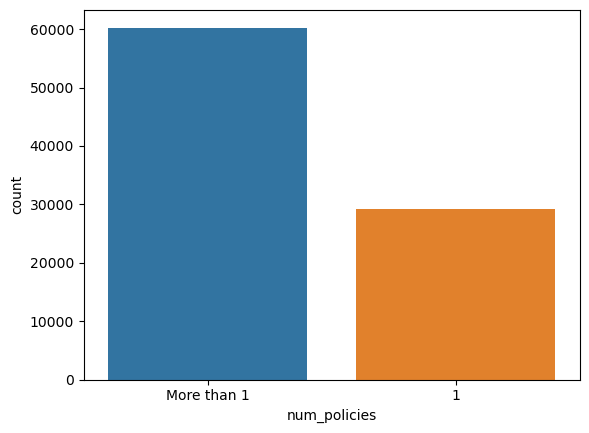

In [ ]:
plt.show(sns.countplot(x=train['num_policies'], hue=train['num_policies']))

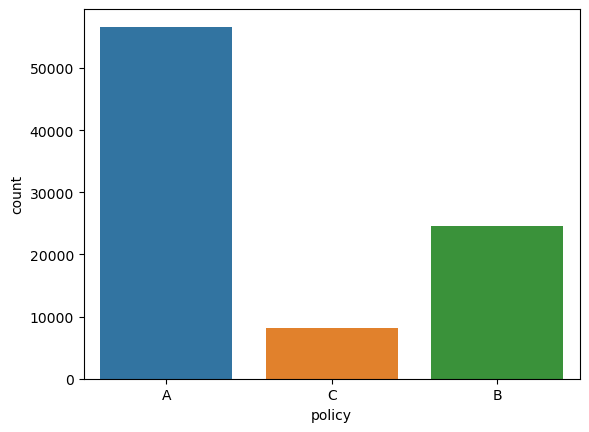

In [ ]:
plt.show(sns.countplot(x=train['policy'], hue=train['policy']))

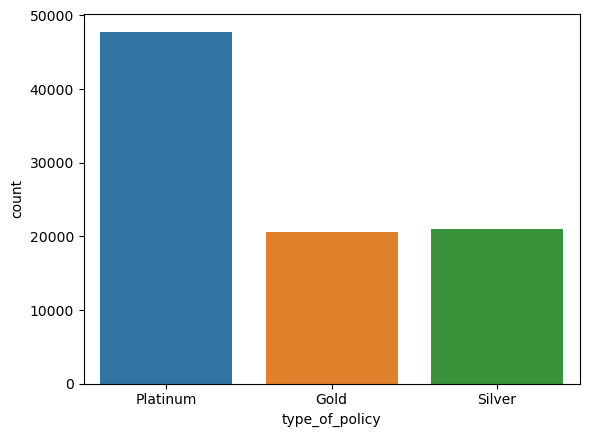

In [ ]:
plt.show(sns.countplot(x=train['type_of_policy'], hue=train['type_of_policy']))

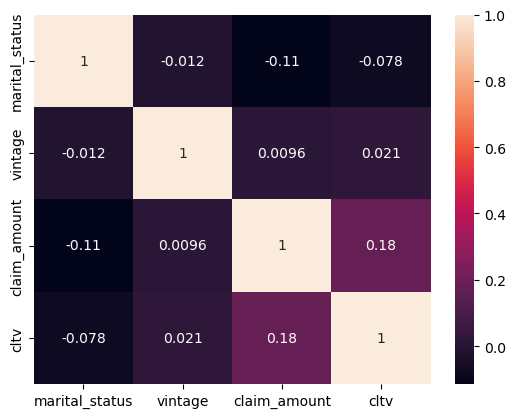

In [ ]:
heatmap = train[['marital_status', 'vintage', 'claim_amount', 'cltv']]
plt.show(sns.heatmap(heatmap.corr(), annot=True))

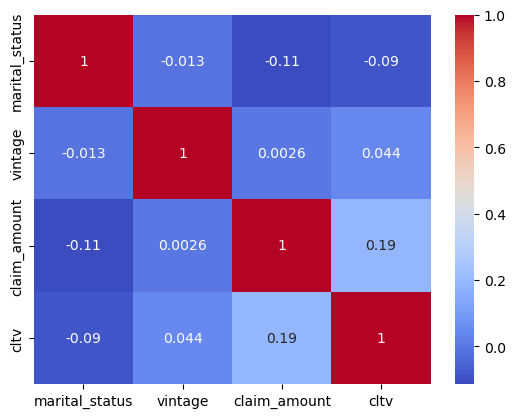

In [ ]:
heatmap = train[['marital_status', 'vintage', 'claim_amount', 'cltv']]
plt.show(sns.heatmap(heatmap.corr(method='spearman'), annot=True, cmap='coolwarm'))

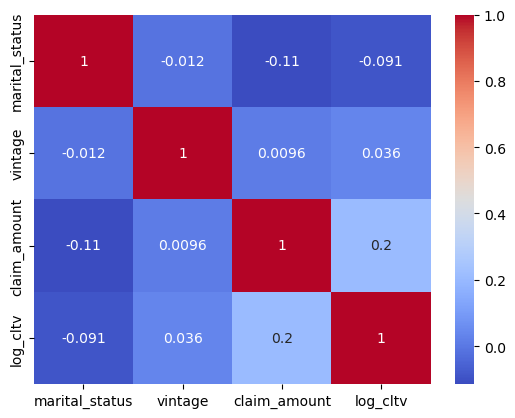

In [ ]:
log_train_df = train[['marital_status', 'vintage', 'claim_amount']].copy()
log_train_df['log_cltv'] = np.log1p(train['cltv'])

plt.show(sns.heatmap(log_train_df.corr(), annot=True, cmap='coolwarm'))

claim amount gives the strongest positive correlation with cltv in the heatmap, showing a weak/moderate correlation while there is effectively no linear relationship between vintage and cltv, we can say the same for marital status.

In [ ]:
from sklearn.preprocessing import PowerTransformer
import numpy as np

# 1. Log Transformation
log_skew = np.log1p(train['cltv']).skew()
log_kurt = np.log1p(train['cltv']).kurtosis()
print(f"Log1p - Skewness: {log_skew:.3f}, Kurtosis: {log_kurt:.3f}")

# 2. Yeo-Johnson Transformation
pt = PowerTransformer(method='yeo-johnson')
yj_cltv = pt.fit_transform(train[['cltv']])
print(f"Yeo-Johnson - Skewness: {float(np.atleast_1d(yj_cltv).skew()):.3f}")

ImportError: DLL load failed while importing _openmp_helpers: The specified module could not be found.